<a href="https://colab.research.google.com/github/bingjunw/ust-deep-learning-2026/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping

dataset_path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")
original_images_dir = os.path.join(dataset_path, "images", "images")
tiled_images_dir = "tiled_dataset_artworks_strict_split"

def split_and_tile_images(src_dir, dest_dir, val_split=0.2):
    train_dir = os.path.join(dest_dir, 'train')
    val_dir = os.path.join(dest_dir, 'val')

    if os.path.exists(dest_dir):
        return

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for artist in os.listdir(src_dir):
        artist_path = os.path.join(src_dir, artist)
        if not os.path.isdir(artist_path): continue

        os.makedirs(os.path.join(train_dir, artist), exist_ok=True)
        os.makedirs(os.path.join(val_dir, artist), exist_ok=True)

        images = os.listdir(artist_path)
        random.seed(42)
        random.shuffle(images)

        split_idx = int(len(images) * (1 - val_split))
        train_imgs = images[:split_idx]
        val_imgs = images[split_idx:]

        def process_images(img_list, save_base_dir):
            for img_name in img_list:
                img_path = os.path.join(artist_path, img_name)
                try:
                    with Image.open(img_path) as img:
                        w, h = img.size
                        mid_w, mid_h = w // 2, h // 2
                        quadrants = [
                            (0, 0, mid_w, mid_h),
                            (mid_w, 0, w, mid_h),
                            (0, mid_h, mid_w, h),
                            (mid_w, mid_h, w, h)
                        ]
                        name_base = os.path.splitext(img_name)[0]
                        for i, quad in enumerate(quadrants):
                          tile = img.crop(quad).convert("RGB")
                          tile_resized = tile.resize((128, 128))
                          tile_resized.save(os.path.join(save_base_dir, artist, f"{name_base}_tile{i}.jpg"))
                except Exception:
                    pass

        process_images(train_imgs, train_dir)
        process_images(val_imgs, val_dir)

split_and_tile_images(original_images_dir, tiled_images_dir)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(tiled_images_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(tiled_images_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

Using Colab cache for faster access to the 'best-artworks-of-all-time' dataset.
Found 27988 images belonging to 51 classes.
Found 7108 images belonging to 51 classes.


In [ ]:
num_classes = train_generator.num_classes

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

vgg_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

vgg_model.compile(optimizer=optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_vgg_initial = vgg_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

vgg_model.compile(optimizer=optimizers.Adam(1e-6), loss='categorical_crossentropy', metrics=['accuracy'])
history_vgg_finetune = vgg_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 85s 87ms/step - accuracy: 0.1527 - loss: 3.3689 - val_accuracy: 0.2015 - val_loss: 3.0968
Epoch 2/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 80s 91ms/step - accuracy: 0.2421 - loss: 2.9277 - val_accuracy: 0.2613 - val_loss: 2.8462
Epoch 3/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 80s 91ms/step - accuracy: 0.2828 - loss: 2.7264 - val_accuracy: 0.2974 - val_loss: 2.7057
Epoch 4/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 79s 91ms/step - accuracy: 0.3112 - loss: 2.5954 - val_accuracy: 0.3108 - val_loss: 2.6173
Epoch 5/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 79s 91ms/step - accuracy: 0.3242 - loss: 2.5049 - val_accuracy: 0.3157 - val_loss: 2.5592
Epoch 6/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 79s 90ms/step - accuracy: 0.3410 - loss: 2.4324 - val_accuracy: 0.3279 - val_loss: 2.5067
Epoch 7/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 79s 91ms/step - accuracy: 0.3533 - loss: 2.3773 - val_accuracy: 0.3412 - val_loss: 2.4651
Epoch 8/20
875/875 ━━━━━━━━━━━━━━━━━━━━

223/223 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step

=== Validation Results ===
VGG Original Accuracy: 0.4585
VGG Scrambled Accuracy: 0.0449


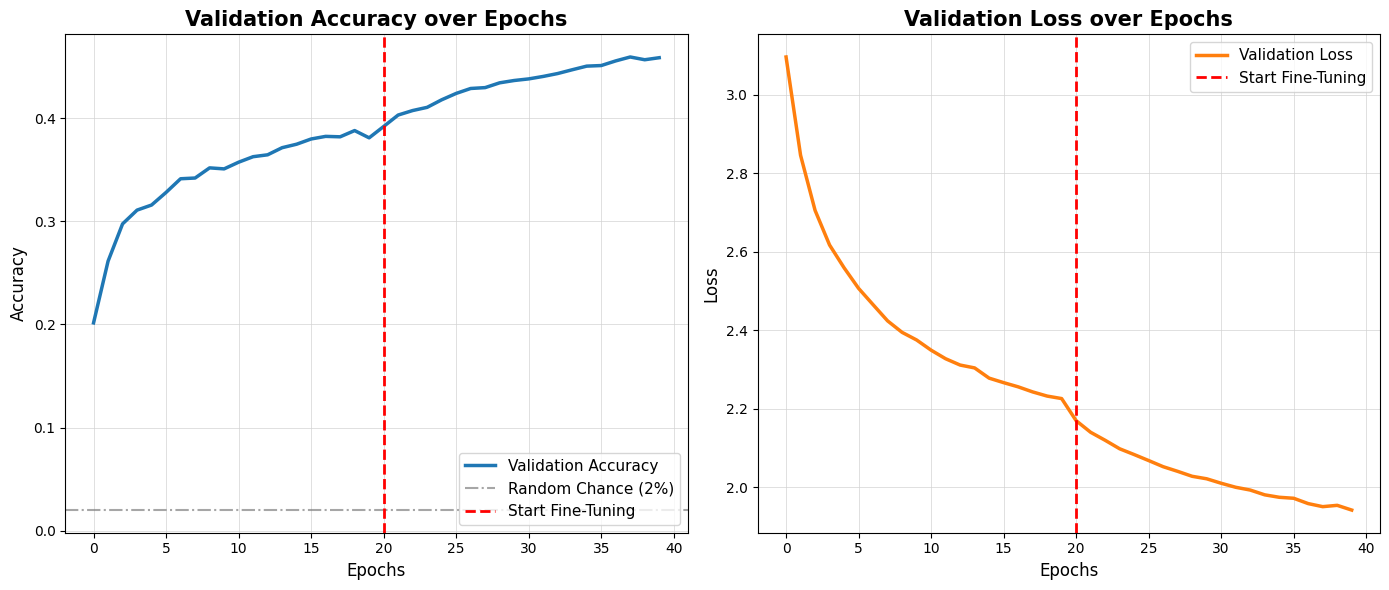

In [10]:
val_generator.reset()
y_pred_probs = vgg_model.predict(val_generator)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

original_acc = np.mean(y_pred_labels == y_true)
y_scrambled = np.random.permutation(y_true)
scrambled_acc = np.mean(y_pred_labels == y_scrambled)

print("\n=== Validation Results ===")
print(f"VGG Original Accuracy: {original_acc:.4f}")
print(f"VGG Scrambled Accuracy: {scrambled_acc:.4f}")

vgg_val_acc = history_vgg_initial.history['val_accuracy'] + history_vgg_finetune.history['val_accuracy']
vgg_val_loss = history_vgg_initial.history['val_loss'] + history_vgg_finetune.history['val_loss']

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(vgg_val_acc, label='Validation Accuracy', color='#1f77b4', linewidth=2.5)
plt.axhline(y=0.02, color='gray', linestyle='-.', label='Random Chance (2%)', alpha=0.7)
plt.axvline(x=20, color='red', linestyle='--', linewidth=2, label='Start Fine-Tuning')
plt.title('Validation Accuracy over Epochs', fontsize=15, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.grid(color='lightgray', linestyle='-', linewidth=0.5)

plt.subplot(1, 2, 2)
plt.plot(vgg_val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2.5)
plt.axvline(x=20, color='red', linestyle='--', linewidth=2, label='Start Fine-Tuning')
plt.title('Validation Loss over Epochs', fontsize=15, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(color='lightgray', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('training_curves_presentation.png', dpi=300)
plt.show()


=== Generating Latent Space (t-SNE) Visualization ===
Extracting 512-D embeddings from validation set...
223/223 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step
Running t-SNE dimensionality reduction (this may take a minute)...


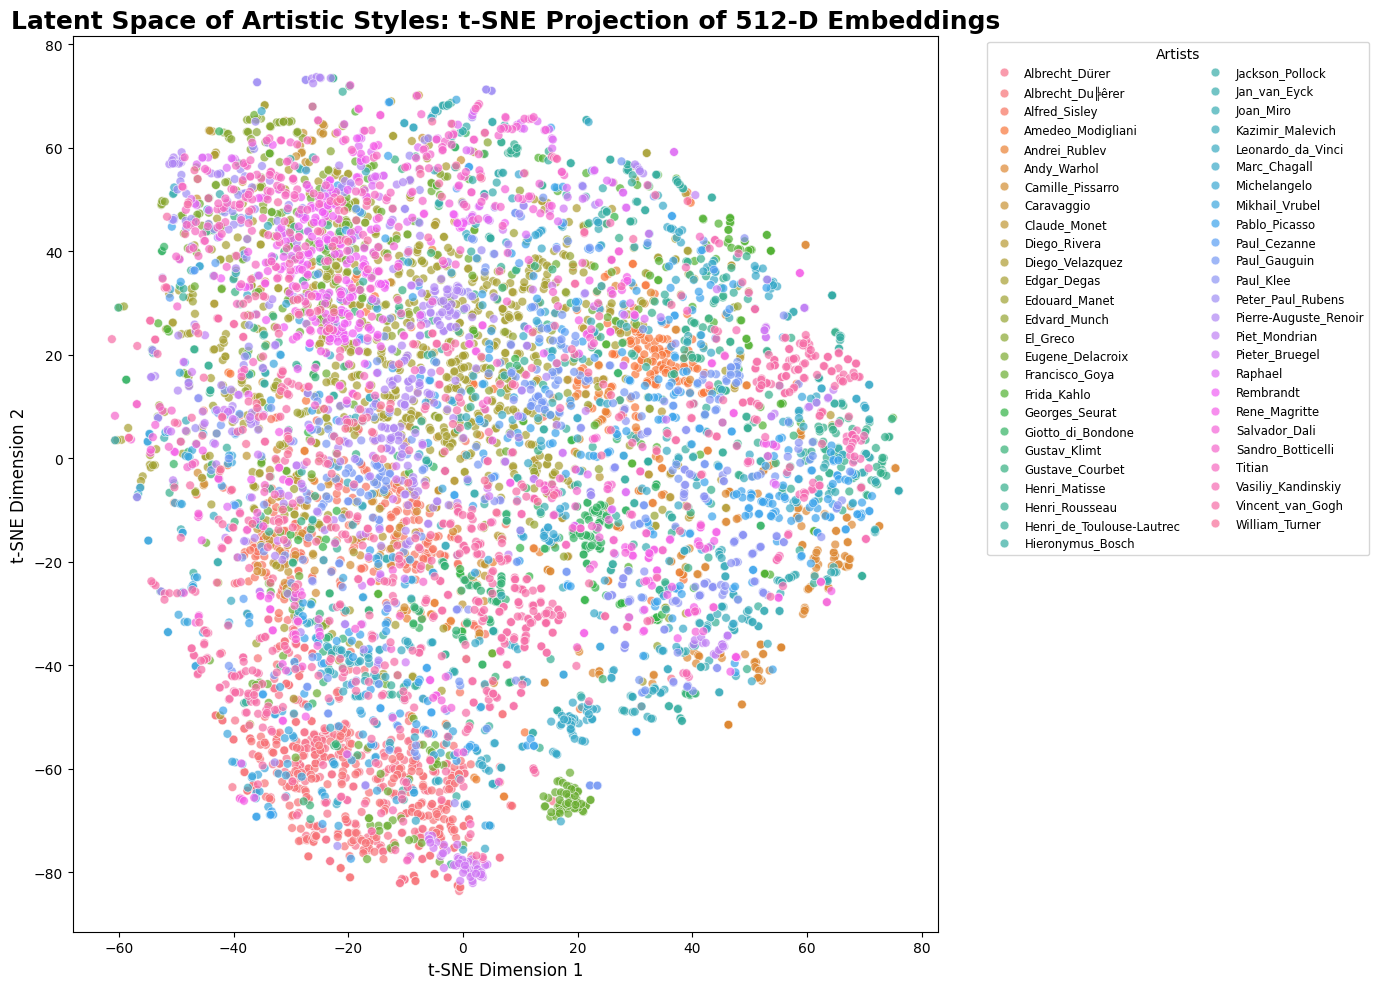

=== t-SNE Visualization Complete ===



In [12]:
from sklearn.manifold import TSNE
import seaborn as sns

print("\n=== Generating Latent Space (t-SNE) Visualization ===")

# Fix: Create a new Sequential model containing layers up to the 512-D Dense layer
feature_extractor = models.Sequential(vgg_model.layers[:3])

print("Extracting 512-D embeddings from validation set...")
val_generator.reset()
features = feature_extractor.predict(val_generator)

true_labels = val_generator.classes

print("Running t-SNE dimensionality reduction (this may take a minute)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(features)

plt.figure(figsize=(14, 10))

label_map = {v: k for k, v in val_generator.class_indices.items()}
label_names = [label_map[label] for label in true_labels]

sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    hue=label_names,
    palette=sns.color_palette("husl", len(label_map)),
    legend="full",
    alpha=0.7,
    s=40
)

plt.title("Latent Space of Artistic Styles: t-SNE Projection of 512-D Embeddings", fontsize=18, fontweight='bold')
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2, title="Artists")

plt.tight_layout()
plt.savefig('latent_space_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

print("=== t-SNE Visualization Complete ===\n")

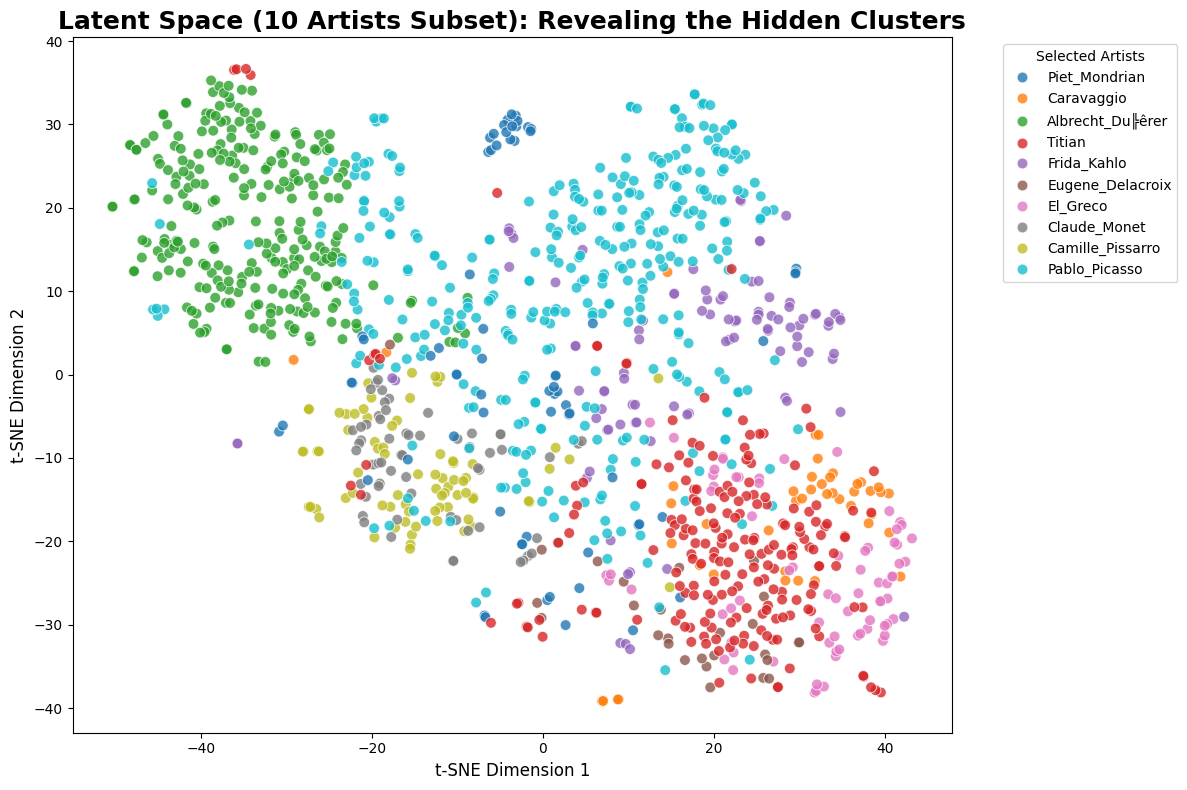

In [16]:
import random
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

num_subset = 10
all_class_indices = list(label_map.keys())
random.seed(42)
selected_indices = random.sample(all_class_indices, num_subset)

mask = np.isin(true_labels, selected_indices)
filtered_features = features[mask]
filtered_labels = true_labels[mask]

tsne_subset = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_subset_results = tsne_subset.fit_transform(filtered_features)

plt.figure(figsize=(12, 8))

filtered_label_names = [label_map[label] for label in filtered_labels]
unique_artist_names = [label_map[idx] for idx in selected_indices]

sns.scatterplot(
    x=tsne_subset_results[:, 0],
    y=tsne_subset_results[:, 1],
    hue=filtered_label_names,
    hue_order=unique_artist_names,
    palette=sns.color_palette("tab10", num_subset),
    legend="full",
    alpha=0.8,
    s=60
)

plt.title("Latent Space (10 Artists Subset): Revealing the Hidden Clusters", fontsize=18, fontweight='bold')
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='medium', title="Selected Artists")

plt.tight_layout()
plt.savefig('latent_space_tsne_10_artists.png', dpi=300, bbox_inches='tight')
plt.show()


=== Generating Confusion Matrix Analysis ===


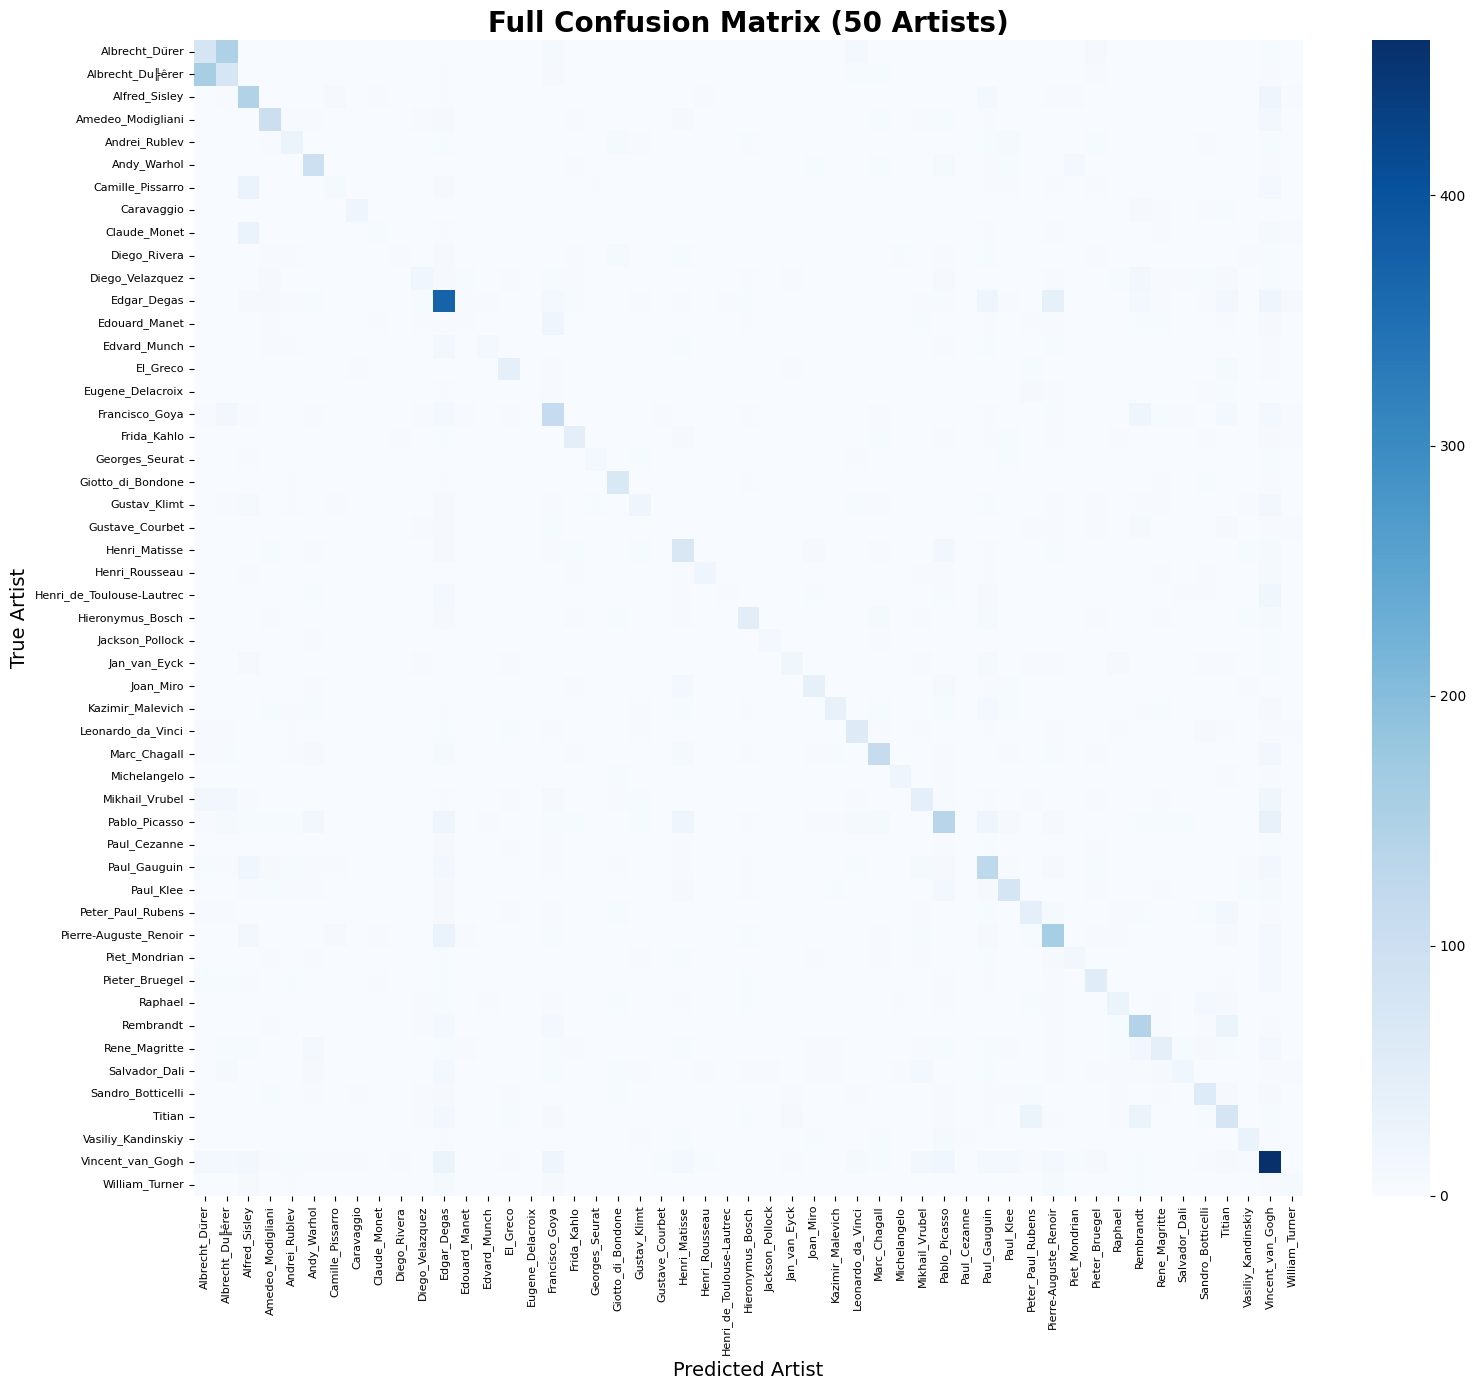


=== Top 5 Most Confused Artist Pairs (Filtered) ===
Model confused the following artists most frequently:
-> True: Edgar_Degas               | Predicted as: Pierre-Auguste_Renoir     | Frequency: 41 times
-> True: Pablo_Picasso             | Predicted as: Vincent_van_Gogh          | Frequency: 35 times
-> True: Camille_Pissarro          | Predicted as: Alfred_Sisley             | Frequency: 32 times
-> True: Claude_Monet              | Predicted as: Alfred_Sisley             | Frequency: 31 times
-> True: Pierre-Auguste_Renoir     | Predicted as: Edgar_Degas               | Frequency: 30 times

=== Confusion Analysis Complete ===


In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

print("\n=== Generating Confusion Matrix Analysis ===")

cm = confusion_matrix(y_true, y_pred_labels)
class_names = list(label_map.values())

plt.figure(figsize=(16, 14))

sns.heatmap(cm, annot=False, cmap='Blues', cbar=True,
            xticklabels=class_names, yticklabels=class_names)

plt.title('Full Confusion Matrix (50 Artists)', fontsize=20, fontweight='bold')
plt.ylabel('True Artist', fontsize=14)
plt.xlabel('Predicted Artist', fontsize=14)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.savefig('confusion_matrix_full.png', dpi=300)
plt.show()

print("\n=== Top 5 Most Confused Artist Pairs (Filtered) ===")

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

sorted_indices = np.argsort(cm_errors, axis=None)[::-1]

valid_pairs_found = 0
print("Model confused the following artists most frequently:")

for idx in sorted_indices:
    true_idx, pred_idx = np.unravel_index(idx, cm_errors.shape)

    true_artist = class_names[true_idx]
    pred_artist = class_names[pred_idx]
    error_count = cm_errors[true_idx, pred_idx]

    if error_count == 0:
        break

    if "Albrecht" in true_artist and "Albrecht" in pred_artist:
        continue

    print(f"-> True: {true_artist:25s} | Predicted as: {pred_artist:25s} | Frequency: {error_count} times")

    valid_pairs_found += 1
    if valid_pairs_found == 5:
        break

print("\n=== Confusion Analysis Complete ===")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import tensorflow as tf
from tensorflow.keras.utils import img_to_array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        vgg16_base = model.get_layer('vgg16')

        feature_extractor_model = tf.keras.Model(
            inputs=vgg16_base.input,
            outputs=vgg16_base.get_layer(last_conv_layer_name).output
        )

        features = feature_extractor_model(img_tensor)
        tape.watch(features)

        x = features
        for layer in model.layers[model.layers.index(vgg16_base) + 1:]:
            x = layer(x)

        preds = x
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, features)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = features[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

def get_top5_from_averaged_preds(avg_preds, label_map):
    top_indices = np.argsort(avg_preds)[-5:][::-1]
    top5_labels = [label_map[i] for i in top_indices]
    top5_confidences = [avg_preds[i] for i in top_indices]
    return top5_labels, top5_confidences

def run_universal_art_analysis(image_paths, model, label_map, layer_name):
    num_images = len(image_paths)
    if num_images == 0:
        return

    fig, axes = plt.subplots(num_images, 2, figsize=(16, 6 * num_images))
    if num_images == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, path in enumerate(image_paths):
        if not os.path.exists(path):
            continue

        filename = os.path.basename(path)
        img = Image.open(path).convert("RGB")
        w, h = img.size
        mid_w, mid_h = w // 2, h // 2
        quadrants = [
            img.crop((0, 0, mid_w, mid_h)),
            img.crop((mid_w, 0, w, mid_h)),
            img.crop((0, mid_h, mid_w, h)),
            img.crop((mid_w, mid_h, w, h))
        ]

        quad_superimposed = []
        preds_list = []

        for quad in quadrants:
            quad_resized = quad.resize((128, 128))
            img_array = img_to_array(quad_resized) / 255.0
            img_array_input = np.expand_dims(img_array, axis=0)

            preds_list.append(model.predict(img_array_input, verbose=0)[0])

            heatmap = make_gradcam_heatmap(img_array_input, model, layer_name)
            heatmap_resized = cv2.resize(heatmap, (128, 128))
            heatmap_cv2 = np.uint8(255 * heatmap_resized)

            heatmap_color = cv2.applyColorMap(heatmap_cv2, cv2.COLORMAP_JET)
            heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

            superimposed = heatmap_color / 255.0 * 0.4 + img_array
            superimposed = superimposed / np.max(superimposed)
            quad_superimposed.append(superimposed)

        avg_preds = np.mean(preds_list, axis=0)
        labels, confs = get_top5_from_averaged_preds(avg_preds, label_map)

        predicted_artist = labels[0]
        top_confidence = confs[0]

        top_row = np.hstack((quad_superimposed[0], quad_superimposed[1]))
        bottom_row = np.hstack((quad_superimposed[2], quad_superimposed[3]))
        stitched_heatmap_img = np.vstack((top_row, bottom_row))

        ax_conf = axes[i, 0]
        y_pos = np.arange(len(labels))

        bar_colors = ['#4e79a7' if (idx == 0 and conf >= 0.3) else '#bab0ac' for idx, conf in enumerate(confs)]
        bars = ax_conf.barh(y_pos, confs, align='center', color=bar_colors)

        ax_conf.set_yticks(y_pos)
        ax_conf.set_yticklabels(labels)
        ax_conf.invert_yaxis()
        ax_conf.set_xlabel('Average Confidence Score (4 Tiles)')

        if top_confidence < 0.3:
            title_text = f'File: {filename}\nPredicted: Cannot determine artist'
        else:
            title_text = f'File: {filename}\nPredicted: {predicted_artist} ({top_confidence*100:.1f}%)'

        ax_conf.set_title(title_text, fontsize=14, fontweight='bold')
        ax_conf.set_xlim(0, 1.0)

        for bar, conf in zip(bars, confs):
            ax_conf.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{conf:.3f}', va='center')

        ax_cam = axes[i, 1]
        ax_cam.imshow(stitched_heatmap_img)
        ax_cam.set_title(f'Grad-CAM Analysis', fontsize=12)
        ax_cam.axis('off')

    plt.tight_layout()
    plt.savefig('universal_art_analysis_results.png')
    plt.show()

In [ ]:
test_images = [
    'van_ai_c.png',
    'van_ai_nc.png',
    'dvc_ai.png',
    'pcs_ai.png',
    'fake1.png',
    'fake.png',
    'fake32.png',
    'jean.png'

]

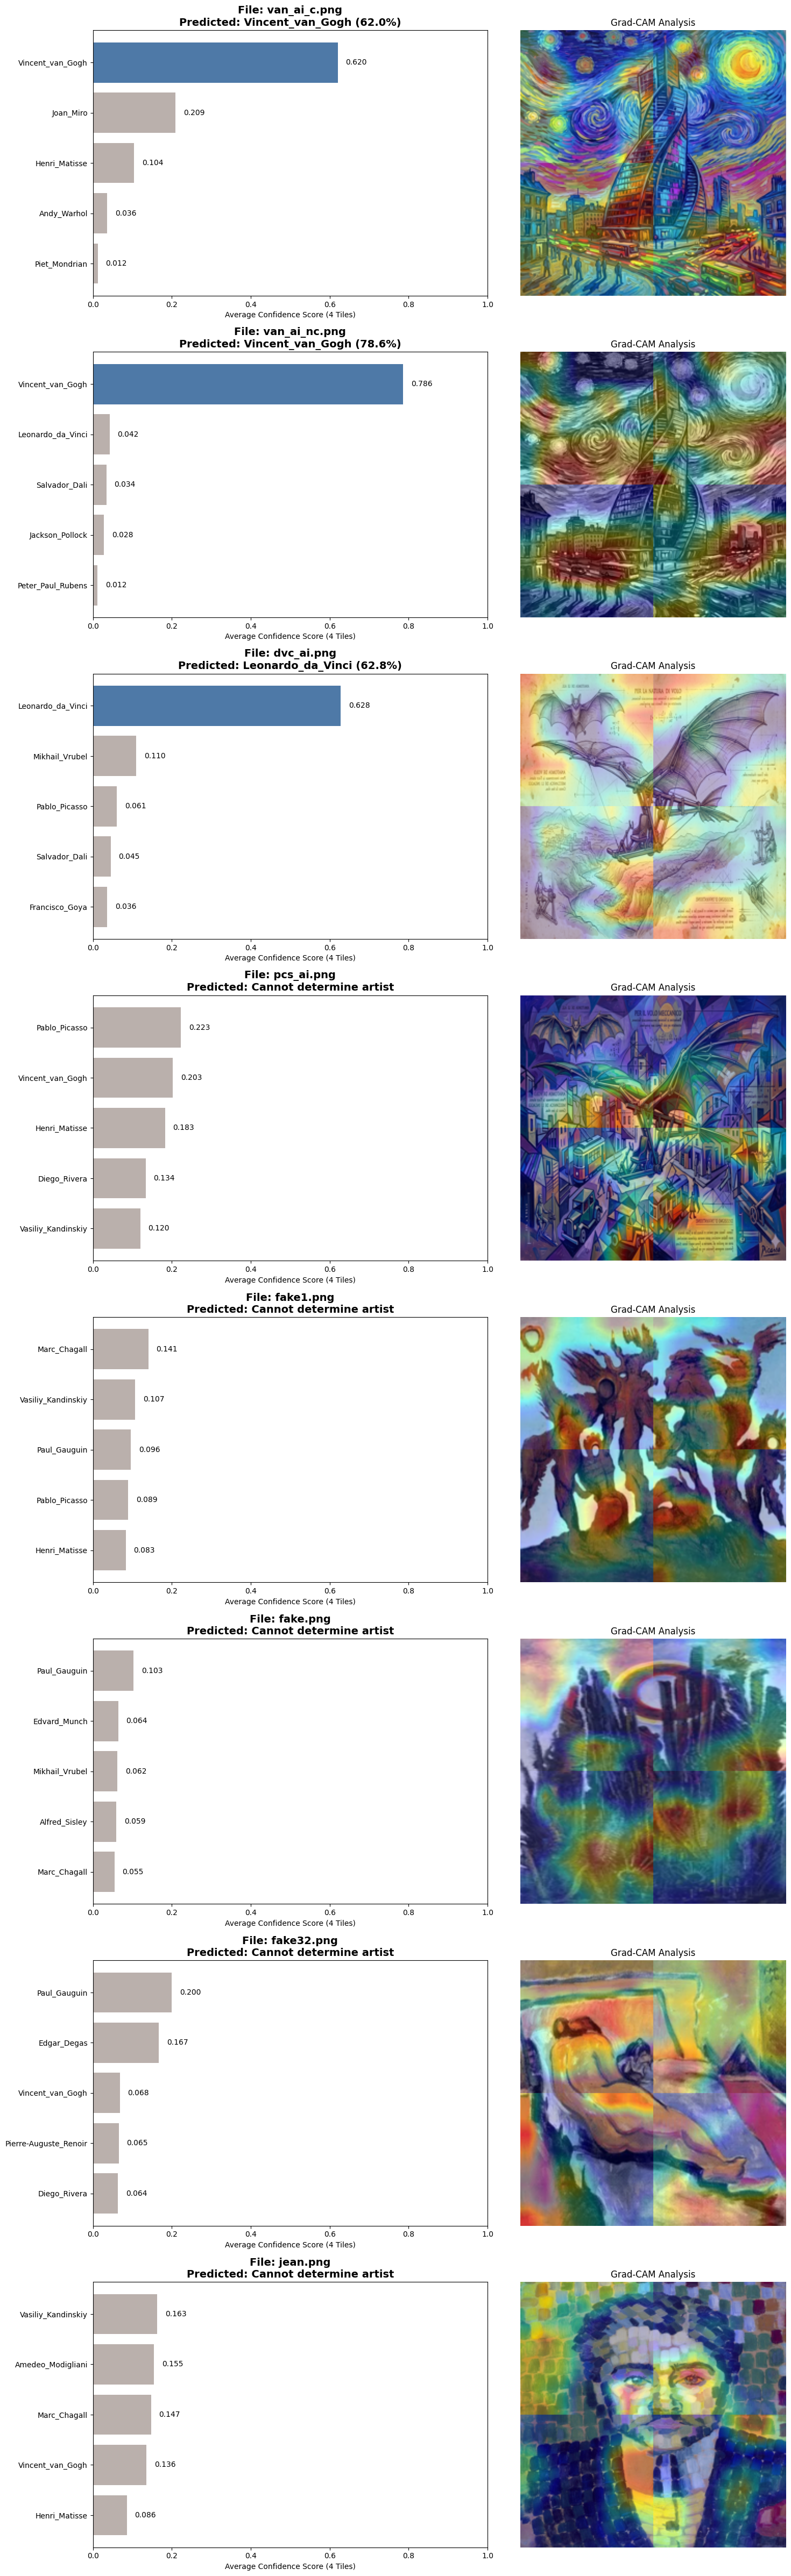

In [ ]:
LAST_CONV_LAYER = 'block5_conv3'

label_map = {v: k for k, v in train_generator.class_indices.items()}

run_universal_art_analysis(
    image_paths=test_images,
    model=vgg_model,
    label_map=label_map,
    layer_name=LAST_CONV_LAYER
)